# Ablation A — MASST TSV Parameter Sweep

Evaluates the **hierarchical GAT model** — identical architecture, node features, and
transductive graph-construction pipeline as `spectral_classifier-hierarchical.ipynb` —
across all 9 MASST result files (`results_t{50,60,70}_e{5,10,20}.tsv`) to study how the
cosine-similarity threshold and edge-limit used to generate the MASST TSV affect
classification performance.

Only the **MASST TSV path** changes between runs. Every other step — transductive
molecular network over all nodes, Leiden community detection on every connected
component, per-community Maximum Weight Spanning Tree, 4 MCN community features, 344-dim
node features, hierarchical GAT-GNN with superclass + class heads, hierarchical inference
masking, and the training procedure — is exactly the same as the hierarchical notebook.

| Parameter | Values |
|-----------|--------|
| Threshold (`t`) | 50, 60, 70 |
| Edge limit (`e`) | 5, 10, 20 |


## 1. Imports

In [1]:
import os, csv, gc
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_edge
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'networkx  : {nx.__version__}')
print(f'igraph    : {ig.__version__}')
print(f'leidenalg : {leidenalg.version}')
print(f'device    : {device}')


C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


networkx  : 3.4.2
igraph    : 1.0.0
leidenalg : 0.12.0
device    : cuda


## 2. Configuration

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Paths
mgf_path          = os.path.expanduser("NIST/NIST_GC_EI_MAX_LIBRARY.mgf")
nist_classes_path = "NIST/nist_classes.csv"
nist_dir          = "C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST"

# All 9 MASST parameter combinations swept in this ablation
MASST_FILES = {
    't50_e5' : f'{nist_dir}/results_t50_e5.tsv',
    't50_e10': f'{nist_dir}/results_t50_e10.tsv',
    't50_e20': f'{nist_dir}/results_t50_e20.tsv',
    't60_e5' : f'{nist_dir}/results_t60_e5.tsv',
    't60_e10': f'{nist_dir}/results_t60_e10.tsv',
    't60_e20': f'{nist_dir}/results_t60_e20.tsv',
    't70_e5' : f'{nist_dir}/results_t70_e5.tsv',
    't70_e10': f'{nist_dir}/results_t70_e10.tsv',
    't70_e20': f'{nist_dir}/results_t70_e20.tsv',
}

# Mode: full dataset or 4-class subset (same toggle as the hierarchical notebook)
use_4class = True
four_classes = [
    "Benzene and substituted derivatives",
    "Carboxylic acids and derivatives",
    "Fatty Acyls",
    "Organooxygen compounds",
]

# Community detection settings (identical to hierarchical notebook)
leiden_seed     = 42     # reproducibility
min_leiden_size = 10     # components below this size -> single community (Leiden not run)

# dataset split settings (identical to hierarchical notebook)
random_state = 42
test_size    = 0.20
val_size     = 0.10

# Model / training hyperparameters (identical to hierarchical notebook)
hidden      = 128
num_layers  = 2
num_heads   = 4
dropout     = 0.3
drop_edge_p = 0.1
epochs      = 200
lr          = 1e-3
patience    = 20
w_sc        = 0.3   # loss weight for superclass head
w_cl        = 0.7   # loss weight for class head (primary task)

def artifact_path(run_name, stem, ext):
    """e.g. results/ablationA_t50_e20_model.pt"""
    return os.path.join(RESULTS_DIR, f"ablationA_{run_name}_{stem}.{ext}")

print(f"Mode          : {'4-class subset' if use_4class else 'Full dataset'}")
print(f"Leiden seed   : {leiden_seed}")
print("MASST files:")
for k, p in MASST_FILES.items():
    print(f"  {k}: exists={os.path.exists(p)}")
print(f"Results dir   : {os.path.abspath(RESULTS_DIR)}")


Mode          : 4-class subset
Leiden seed   : 42
MASST files:
  t50_e5: exists=True
  t50_e10: exists=True
  t50_e20: exists=True
  t60_e5: exists=True
  t60_e10: exists=True
  t60_e20: exists=True
  t70_e5: exists=True
  t70_e10: exists=True
  t70_e20: exists=True
Results dir   : C:\Users\bibhushaojha\Desktop\graph-based-spectral-classifier\results


## 3. Data Loading

Load spectra + labels once, shared by every sweep run. The split is defined here so the
training loss can later be masked to training nodes. The molecular network itself is
rebuilt **per MASST file** over all nodes (transductive) purely from spectral similarity
— community detection never uses labels, so every run in the sweep stays leakage-free.

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == "BEGIN IONS":  inside, meta, peaks = True, {}, []; continue
            if line == "END IONS":
                if inside:
                    entries.append({
                        "meta": meta.copy(),
                        "peaks": np.array(peaks, dtype=float) if peaks else np.empty((0,2), dtype=float),
                    })
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if "=" in line:
                k, v = line.split('=', 1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries


def read_nist_classes_csv(path):
    label_map = {}
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for row in csv.DictReader(f):
            sid = int(row["file"].strip())
            sk  = row["Superklass"].strip()
            k   = row["klass"].strip()
            label_map[sid] = {
                "superclass": None if sk == "null" else sk,
                "klass":      None if (k == "null" or k.startswith("subklass:")) else k,
            }
    return label_map


print("Loading MGF ...")
mgf_entries = parse_mgf_file(mgf_path)
print(f"  {len(mgf_entries):,} entries")

print("Loading labels ...")
nist_label_map = read_nist_classes_csv(nist_classes_path)
print(f"  {len(nist_label_map):,} labeled")

# Build dataset (scan_id -> peaks + labels), identical filter to the hierarchical notebook
dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'], 'superclass': lbl['superclass'], 'klass': lbl['klass']})

print(f'Spectra with both superclass + class labels: {len(dataset):,}')

superclass_counts = Counter(r['superclass'] for r in dataset)
print(f'\nUnique superclasses: {len(superclass_counts)}')

klass_counts = Counter(r['klass'] for r in dataset)
print(f'Unique classes: {len(klass_counts)}')

# 4-class filter (only used when use_4class = True) — same as hierarchical notebook
if use_4class:
    dataset = [r for r in dataset if r['klass'] in four_classes]
    print(f'\nAfter 4-class filter: {len(dataset):,} spectra')
    for cls in four_classes:
        n = sum(1 for r in dataset if r['klass'] == cls)
        print(f'  {n:7,}  {cls}')

    superclass_counts = Counter(r['superclass'] for r in dataset)
    print(f'\nUnique superclasses after 4-class filter: {len(superclass_counts)}')
    for sc, cnt in superclass_counts.most_common():
        print(f'  {cnt:7,}  {sc}')
else:
    print(f'\nUsing full dataset: {len(dataset):,} spectra')


Loading MGF ...
  193,121 entries
Loading labels ...
  193,121 labeled
Spectra with both superclass + class labels: 183,882

Unique superclasses: 23
Unique classes: 439

After 4-class filter: 84,692 spectra
   42,292  Benzene and substituted derivatives
   17,819  Carboxylic acids and derivatives
   13,925  Fatty Acyls
   10,656  Organooxygen compounds

Unique superclasses after 4-class filter: 4
   42,292  Benzenoids
   17,819  Organic acids and derivatives
   13,925  Lipids and lipid-like molecules
   10,656  Organic oxygen compounds


## 4. Split (Transductive Node Ordering)

Same 70/10/20 stratified train/val/test split as the hierarchical notebook.
`node_order_indices` / `scan_to_pos` fix a **global node ordering** used by every
downstream tensor (features, labels, masks, graph edges) across the whole sweep.

In [4]:
all_idx    = list(range(len(dataset)))
all_labels = [r['klass'] for r in dataset]

label_counts = Counter(all_labels)
keep         = [i for i in all_idx if label_counts[all_labels[i]] >= 2]
keep_labels  = [all_labels[i] for i in keep]
dropped      = {lbl for lbl, cnt in label_counts.items() if cnt < 2}
print(f"Dropped {len(dropped)} singleton classes, {len(all_idx) - len(keep)} samples removed")

# Step 1: hold out test (20%)
tr_val, te_idx = train_test_split(
    keep, test_size=test_size,
    stratify=keep_labels, random_state=random_state)

# Step 2: split remaining into train (70%) / val (10%)
val_rel = val_size / (1.0 - test_size)
tr_idx, va_idx = train_test_split(
    tr_val, test_size=val_rel,
    stratify=[all_labels[i] for i in tr_val],
    random_state=random_state)

train_scan_ids = {dataset[i]['scan_id'] for i in tr_idx}
val_scan_ids   = {dataset[i]['scan_id'] for i in va_idx}
test_scan_ids  = {dataset[i]['scan_id'] for i in te_idx}

assert not (train_scan_ids & val_scan_ids),  'train/val overlap!'
assert not (train_scan_ids & test_scan_ids), 'train/test overlap!'

# global node ordering -> needed to convert MCN edges to GNN indices
node_order_indices = sorted(r['scan_id'] for r in dataset)
scan_to_pos         = {sid: i for i, sid in enumerate(node_order_indices)}
scan_to_ds_idx       = {r['scan_id']: i for i, r in enumerate(dataset)}
n_nodes              = len(node_order_indices)

print(f'scan_to_pos defined: {n_nodes:,} nodes')
print(f'Split complete (random_state={random_state}):')
print(f'  Train : {len(train_scan_ids):,}  ({len(train_scan_ids)/len(dataset)*100:.1f}%)')
print(f'  Val   : {len(val_scan_ids):,}  ({len(val_scan_ids)/len(dataset)*100:.1f}%)')
print(f'  Test  : {len(test_scan_ids):,}  ({len(test_scan_ids)/len(dataset)*100:.1f}%)')
print('No leakage detected')


Dropped 0 singleton classes, 0 samples removed
scan_to_pos defined: 84,692 nodes
Split complete (random_state=42):
  Train : 59,283  (70.0%)
  Val   : 8,470  (10.0%)
  Test  : 16,939  (20.0%)
No leakage detected


## 5. Build Spectral Node Features

Identical 340-dim `peaks_to_features` encoding as the hierarchical notebook. Computed
once (independent of the MASST graph) and normalised using **training-node statistics
only**.

In [5]:
def peaks_to_features(peaks, top_k=20):
    """
    Convert a spectrum to a 340-dim feature vector.
    Each of the top-20 peaks (by intensity) contributes 17 features:
      - 16: sinusoidal m/z encoding (8 sin + 8 cos at log-spaced wavelengths)
      -  1: normalised intensity
    """
    n_out = top_k * 17

    # empty spectrum -> zero vector
    if peaks is None or len(peaks) == 0:
        return np.zeros(n_out, dtype=np.float32)

    p = peaks.astype(np.float32)

    # keep top-k peaks by intensity; zero-pad if fewer than top_k
    p = p[np.argsort(p[:, 1])[::-1][:top_k]]
    if len(p) < top_k:
        pad = np.zeros((top_k - len(p), 2), dtype=np.float32)
        p   = np.vstack([p, pad])

    mz    = p[:, 0]                          # (top_k,)
    inten = p[:, 1]
    inten = inten / max(inten.max(), 1e-6)   # normalise to 0-1

    # 8 wavelengths log-spaced between 0.1 and 1000 Da
    wavelengths = np.logspace(-1, 3, num=8, dtype=np.float32)   # (8,)

    # sinusoidal encoding of m/z: sin and cos at each wavelength
    angles = (2 * np.pi * mz[:, None]) / wavelengths[None, :]   # (top_k, 8)
    sin_enc = np.sin(angles)   # (top_k, 8)
    cos_enc = np.cos(angles)   # (top_k, 8)

    # interleave sin/cos -> (top_k, 16), then append intensity -> (top_k, 17)
    enc = np.empty((top_k, 16), dtype=np.float32)
    enc[:, 0::2] = sin_enc
    enc[:, 1::2] = cos_enc
    features = np.concatenate([enc, inten[:, None]], axis=1)   # (top_k, 17)

    return features.flatten()   # (340,)


# build features for all nodes
print('Building spectral features for all nodes ...')
raw_x = np.stack(
    [peaks_to_features(dataset[scan_to_ds_idx[sid]]['peaks'])
     for sid in node_order_indices],
    axis=0
).astype(np.float32)
print(f'raw_x shape : {raw_x.shape}  (n_nodes x 340)')

# normalise using training statistics only (no leakage)
train_rows = np.array([scan_to_pos[sid] for sid in train_scan_ids
                       if sid in scan_to_pos], dtype=np.int64)
feat_mean  = raw_x[train_rows].mean(axis=0, keepdims=True)
feat_std   = raw_x[train_rows].std(axis=0,  keepdims=True).clip(min=1e-6)
x_spec     = ((raw_x - feat_mean) / feat_std).astype(np.float32)

print(f'Normalised on {len(train_rows):,} training nodes only')
print(f'x_spec shape : {x_spec.shape}')


Building spectral features for all nodes ...
raw_x shape : (84692, 340)  (n_nodes x 340)
Normalised on 59,283 training nodes only
x_spec shape : (84692, 340)


## 6. Labels, Masks & Hierarchy Constraint

Label encoding, train/val/test boolean masks, the superclass→class hierarchy mask used
at inference, and inverse-frequency class weights — all identical to the hierarchical
notebook and shared across every sweep run (they don't depend on the MASST graph).

In [6]:
all_sc_labels = sorted(set(r['superclass'] for r in dataset if r['superclass'].strip()))
all_cl_labels = sorted(set(r['klass']      for r in dataset if r['klass'].strip()))
le_sc = LabelEncoder(); le_sc.fit(all_sc_labels)
le_cl = LabelEncoder(); le_cl.fit(all_cl_labels)
n_sc  = len(le_sc.classes_)
n_cl  = len(le_cl.classes_)

sid_to_labels = {r['scan_id']: r for r in dataset}

# -1 sentinel for nodes with empty/missing labels
y_sc = [
    int(le_sc.transform([sid_to_labels[sid]['superclass']])[0])
    if sid in sid_to_labels and sid_to_labels[sid]['superclass'].strip() else -1
    for sid in node_order_indices
]
y_cl = [
    int(le_cl.transform([sid_to_labels[sid]['klass']])[0])
    if sid in sid_to_labels and sid_to_labels[sid]['klass'].strip() else -1
    for sid in node_order_indices
]
y_sc_dev = torch.tensor(y_sc, dtype=torch.long).to(device)
y_cl_dev = torch.tensor(y_cl, dtype=torch.long).to(device)

# Boolean masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask   = torch.zeros(n_nodes, dtype=torch.bool)
test_mask  = torch.zeros(n_nodes, dtype=torch.bool)
for i, sid in enumerate(node_order_indices):
    if   sid in train_scan_ids: train_mask[i] = True
    elif sid in val_scan_ids:   val_mask[i]   = True
    elif sid in test_scan_ids:  test_mask[i]  = True

# Exclude nodes with missing labels from all masks
valid_label_mask = torch.tensor([v != -1 for v in y_cl], dtype=torch.bool)
train_mask = train_mask & valid_label_mask
val_mask   = val_mask   & valid_label_mask
test_mask  = test_mask  & valid_label_mask

train_mask_dev = train_mask.to(device)
val_mask_dev   = val_mask.to(device)
test_mask_dev  = test_mask.to(device)
print(f'Masks: train={train_mask.sum():,}  val={val_mask.sum():,}  test={test_mask.sum():,}')

# hierarchy mask: sc_to_cl_mask[sc_id, cl_id] = True means cl is a valid child of sc
# used at inference to mask impossible class predictions (hierarchical constraint)
sc_to_cl_mask = torch.zeros(n_sc, n_cl, dtype=torch.bool)
for r in dataset:
    if not r['superclass'] or not r['klass']: continue
    sc_id = int(le_sc.transform([r['superclass']])[0])
    cl_id = int(le_cl.transform([r['klass']])[0])
    sc_to_cl_mask[sc_id, cl_id] = True
sc_to_cl_mask_dev = sc_to_cl_mask.to(device)
print(f'Hierarchy mask : {sc_to_cl_mask.shape}  '
      f'(avg valid classes/superclass = {sc_to_cl_mask.float().sum(1).mean():.1f})')

# class weights (inverse frequency on training nodes)
def make_class_weights(y_tensor, mask, n_classes):
    counts = np.bincount(y_tensor[mask].cpu().numpy(), minlength=n_classes).astype(float)
    w = 1.0 / counts.clip(min=1)
    return torch.tensor((w / w.sum() * n_classes).astype(np.float32)).to(device)

sc_wts = make_class_weights(y_sc_dev, train_mask_dev, n_sc)
cl_wts = make_class_weights(y_cl_dev, train_mask_dev, n_cl)
print(f'SC class weights: min={sc_wts.min():.3f}  max={sc_wts.max():.3f}')
print(f'CL class weights: min={cl_wts.min():.3f}  max={cl_wts.max():.3f}')


Masks: train=59,283  val=8,470  test=16,939
Hierarchy mask : torch.Size([4, 4])  (avg valid classes/superclass = 1.0)
SC class weights: min=0.385  max=1.530
CL class weights: min=0.385  max=1.530


## 7. Build Transductive Molecular Network + MCN (per MASST file)

For each MASST TSV in the sweep, rebuild the **exact same transductive pipeline** as the
hierarchical notebook:

1. Load MASST cosine-similarity edges over **all** nodes (train + val + test), indexed by
   global node position.
2. Leiden community detection on every connected component (isolated -> singleton
   community, size < `min_leiden_size` -> one community, else Leiden).
3. Maximum Weight Spanning Tree (MWST) within every community.
4. 4 MCN community features (`log_size`, `degree_cent`, `dist_centroid`,
   `singleton_flag`) computed for all nodes.
5. Bidirectional MWST edge tensors used **identically for training and evaluation** —
   message passing spans all nodes, the loss is masked to training nodes only, so this
   stays leakage-free transductive learning, exactly like the hierarchical notebook.

Only the input TSV path changes between sweep runs.

In [7]:
def build_transductive_mcn(masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
                            min_leiden_size=10, leiden_seed=42):
    """Build the transductive MCN pipeline for ONE MASST TSV file.

    Identical algorithm to spectral_classifier-hierarchical.ipynb (sections 4-13):
      1. Read MASST pairwise cosine-similarity edges, keep edges where both endpoints
         are in the dataset, index nodes by GLOBAL position (transductive: all nodes,
         not just train) -- only spectral similarity drives the graph, labels are
         never touched.
      2. Leiden community detection on every connected component.
      3. Maximum Weight Spanning Tree (MWST) within every community -- keeps the
         highest-cosine edges as the GNN graph.
      4. 4 MCN community features for ALL nodes: log_size, degree_cent,
         dist_to_centroid, singleton_flag.
      5. Bidirectional edge tensors -- the SAME graph is returned for both training
         and evaluation (transductive), exactly like the hierarchical notebook.

    Returns
    -------
    x_aug_dev      : (n_nodes, 344) tensor, spectral + community features, on device
    mcn_edge_index : (2, E) bidirectional edge index, on device
    mcn_edge_attr  : (E, 1) cosine-similarity edge weights, on device
    info           : dict of diagnostics (n_edges, n_communities, n_mst_edges,
                      n_singletons, mean_purity)
    """
    all_scan_ids = set(scan_to_pos)

    # 1. Build the network over ALL nodes
    pairs = []
    for chunk in pd.read_csv(
            masst_tsv_path, sep='\t',
            usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
            dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
            chunksize=500_000):
        chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
        chunk = chunk[chunk['scan_1'].isin(all_scan_ids) & chunk['scan_2'].isin(all_scan_ids)]
        if len(chunk) == 0:
            continue
        u = chunk['scan_1'].map(scan_to_pos).to_numpy()
        v = chunk['scan_2'].map(scan_to_pos).to_numpy()
        pairs.append(np.column_stack([np.minimum(u, v), np.maximum(u, v),
                                      chunk['dot_product_shifted'].to_numpy()]))

    allp = np.concatenate(pairs, axis=0) if pairs else np.zeros((0, 3), dtype=np.float32)
    edf  = pd.DataFrame({'u': allp[:, 0].astype(np.int64),
                         'v': allp[:, 1].astype(np.int64),
                         'cosine_score': allp[:, 2].astype(np.float32)})
    edf  = edf.groupby(['u', 'v'], as_index=False)['cosine_score'].max()

    G = nx.from_pandas_edgelist(edf, 'u', 'v', edge_attr='cosine_score')
    G.add_nodes_from(range(n_nodes))   # ensure isolated nodes are included

    # 2. Leiden community detection on every connected component
    all_components = sorted(nx.connected_components(G), key=len, reverse=True)
    mcn_pos_to_comm = {}
    next_comm_id    = 0
    for comp_nodes in all_components:
        size = len(comp_nodes)
        if size == 1:
            node = list(comp_nodes)[0]
            mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        elif size < min_leiden_size:
            for node in comp_nodes:
                mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        else:
            comp_nodes_sorted = sorted(comp_nodes)
            local_remap       = {old: new for new, old in enumerate(comp_nodes_sorted)}
            subgraph          = G.subgraph(comp_nodes_sorted)

            ig_comp = ig.Graph(n=size, directed=False)
            ig_comp.add_edges([(local_remap[u], local_remap[v]) for u, v in subgraph.edges()])
            ig_comp.es['weight'] = [subgraph.edges[u, v]['cosine_score'] for u, v in subgraph.edges()]

            part = leidenalg.find_partition(
                ig_comp, leidenalg.ModularityVertexPartition,
                weights='weight', seed=leiden_seed)

            for local_i, mcn_pos in enumerate(comp_nodes_sorted):
                mcn_pos_to_comm[mcn_pos] = next_comm_id + int(part.membership[local_i])
            next_comm_id += len(part)
    n_communities = next_comm_id
    singleton_nodes = {node for node in G.nodes() if G.degree(node) == 0}

    # 3. Maximum Weight Spanning Tree per community
    comm_to_nodes = defaultdict(list)
    for mcn_pos, comm_id in mcn_pos_to_comm.items():
        comm_to_nodes[comm_id].append(mcn_pos)

    mst_edges = []
    for cid in range(n_communities):
        members = comm_to_nodes[cid]
        if len(members) <= 1:
            continue
        local_idx       = {mcn_pos: i for i, mcn_pos in enumerate(members)}
        n_c             = len(members)
        rows, cols, wts = [], [], []
        for u in members:
            for v in G.neighbors(u):
                if mcn_pos_to_comm.get(v) == cid and v in local_idx:
                    rows.append(local_idx[u])
                    cols.append(local_idx[v])
                    wts.append(G.edges[u, v]['cosine_score'])
        if not rows:
            continue
        mat = _csr_mat((np.array(wts, dtype=np.float32), (rows, cols)), shape=(n_c, n_c))
        neg = mat.copy(); neg.data *= -1
        mst = _mst_func(neg).tocoo(); mst.data *= -1
        for r, c, w in zip(mst.row, mst.col, mst.data):
            mst_edges.append((members[r], members[c], float(w)))

    # 4. Bidirectional edge tensors -- SAME graph used for train and eval
    if mst_edges:
        src_list = [u for u, v, w in mst_edges]
        dst_list = [v for u, v, w in mst_edges]
        wts_list = [w for u, v, w in mst_edges]
        src_bi = src_list + dst_list
        dst_bi = dst_list + src_list
        wts_bi = wts_list + wts_list
        mcn_edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)
        mcn_edge_attr  = torch.tensor(wts_bi, dtype=torch.float32).unsqueeze(1)
    else:
        mcn_edge_index = torch.zeros((2, 0), dtype=torch.long)
        mcn_edge_attr  = torch.zeros((0, 1), dtype=torch.float32)

    # 5. Community features for ALL nodes (transductive)
    node_comm_id   = np.array([mcn_pos_to_comm[i] for i in range(n_nodes)], dtype=np.int64)
    comm_sizes_arr = np.bincount(node_comm_id, minlength=n_communities)

    comm_centroids = np.zeros((n_communities, x_spec.shape[1]), dtype=np.float32)
    np.add.at(comm_centroids, node_comm_id, x_spec)
    comm_centroids /= np.maximum(comm_sizes_arr[:, None], 1)

    f_log_size = np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)

    degree_arr    = np.array([G.degree(i) for i in range(n_nodes)], dtype=np.float32)
    size_m1       = np.maximum(comm_sizes_arr[node_comm_id] - 1, 1).astype(np.float32)
    f_degree_cent = (degree_arr / size_m1).clip(0, 1)

    diffs       = x_spec - comm_centroids[node_comm_id]
    f_dist_cent = np.linalg.norm(diffs, axis=1).astype(np.float32)

    f_singleton = np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],
                           dtype=np.float32)

    comm_features = np.stack([f_log_size, f_degree_cent, f_dist_cent, f_singleton], axis=1).astype(np.float32)
    x_aug = np.concatenate([x_spec, comm_features], axis=1).astype(np.float32)

    # Community class purity -- diagnostic only, never used by the model
    sid_to_klass = {r['scan_id']: r['klass'] for r in dataset}
    comm_members = defaultdict(list)
    for pos in range(n_nodes):
        comm_members[node_comm_id[pos]].append(pos)
    purities = []
    for cid in range(n_communities):
        klasses = [sid_to_klass[node_order_indices[p]]
                   for p in comm_members.get(cid, [])
                   if node_order_indices[p] in sid_to_klass]
        if not klasses:
            continue
        dominant_n = Counter(klasses).most_common(1)[0][1]
        purities.append(dominant_n / len(klasses))
    mean_purity = float(np.mean(purities)) if purities else float('nan')

    info = {
        'n_edges':       G.number_of_edges(),
        'n_communities': n_communities,
        'n_mst_edges':   len(mst_edges),
        'n_singletons':  len(singleton_nodes),
        'mean_purity':   mean_purity,
    }

    x_aug_dev      = torch.tensor(x_aug, dtype=torch.float32).to(device)
    mcn_edge_index = mcn_edge_index.to(device)
    mcn_edge_attr  = mcn_edge_attr.to(device)

    return x_aug_dev, mcn_edge_index, mcn_edge_attr, info


print('build_transductive_mcn() defined.')


build_transductive_mcn() defined.


## 8. Model Architecture

In [8]:
class SpecGNNBlock(nn.Module):
    """One GAT layer with DropEdge + residual + LayerNorm.
    Identical to the hierarchical notebook's block -- no changes.
    """
    def __init__(self, in_ch, out_ch, num_heads=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        assert out_ch % num_heads == 0
        self.drop_edge_p = drop_edge_p
        self.conv = GATConv(
            in_ch, out_ch // num_heads, heads=num_heads,
            concat=True, dropout=dropout, edge_dim=1,
            add_self_loops=False,
        )
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, training=False):
        if training and self.drop_edge_p > 0:
            edge_index, mask = dropout_edge(
                edge_index, p=self.drop_edge_p,
                force_undirected=True, training=True,
            )
            edge_attr = edge_attr[mask]
        h = self.act(self.conv(x, edge_index, edge_attr=edge_attr))
        return self.norm(self.drop(h) + self.res(x))   # residual connection


class HierarchicalSpecGNN(nn.Module):
    """Hierarchical GAT-GNN for superclass + class prediction.

    Identical architecture to the hierarchical notebook:
        Input (344-dim) -> LayerNorm -> Linear projection (128-dim)
        -> N x SpecGNNBlock (GAT + residual + LayerNorm)
        -> Jump-Knowledge concat -> Linear (128-dim)
        -> Superclass head (n_sc logits)
        -> Class head      (n_cl logits)

    At inference, class logits are masked by the predicted superclass so the model can
    never predict a class inconsistent with its superclass.
    """
    def __init__(self, feat_dim=344, hidden=128, num_layers=2, num_heads=4,
                 n_superclass=4, n_class=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        self.norm_in = nn.LayerNorm(feat_dim)
        self.proj    = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden),
            nn.GELU(), nn.Dropout(dropout),
        )
        self.layers = nn.ModuleList([
            SpecGNNBlock(hidden, hidden, num_heads, dropout, drop_edge_p)
            for _ in range(num_layers)
        ])
        self.jk = nn.Sequential(
            nn.Linear(hidden * (num_layers + 1), hidden),
            nn.LayerNorm(hidden), nn.GELU(),
        )
        self.sc_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, n_superclass),
        )
        self.cl_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, n_class),
        )

    def encode(self, x, edge_index, edge_attr, training=False):
        x  = self.norm_in(x)
        h  = self.proj(x)
        hs = [h]
        for layer in self.layers:
            h = layer(h, edge_index, edge_attr, training=training)
            hs.append(h)
        return self.jk(torch.cat(hs, dim=-1))

    def forward(self, x, edge_index, edge_attr, training=False):
        emb = self.encode(x, edge_index, edge_attr, training=training)
        return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, edge_index, edge_attr, sc_to_cl_mask_dev):
        """Inference with hierarchical constraint: class logits inconsistent with the
        predicted superclass are set to -inf before softmax (zero probability)."""
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg = self.forward(x, edge_index, edge_attr)
            valid_mask   = sc_to_cl_mask_dev[sc_lg.argmax(1)]
            cl_lg_masked = cl_lg.masked_fill(~valid_mask, float('-inf'))
        return sc_lg, cl_lg_masked


print('HierarchicalSpecGNN defined.')


HierarchicalSpecGNN defined.


## 9. Training Function (Hierarchical Transductive Training)

Same training procedure as the hierarchical notebook: AdamW + ReduceLROnPlateau on val
class-F1, weighted cross-entropy on both heads (`w_sc` / `w_cl`), gradient clipping,
early stopping on val class macro-F1, best-checkpoint restore, and hierarchical-masked
inference on the test split. Wrapped as a function so it can be called once per MASST
file in the sweep.

In [9]:
def train_and_eval(run_name, x_aug_dev, mcn_ei_dev, mcn_ea_dev):
    """Train + evaluate the HierarchicalSpecGNN for one MASST sweep run.

    Same transductive training procedure as spectral_classifier-hierarchical.ipynb: the
    SAME graph (mcn_ei_dev / mcn_ea_dev) is used for both training and evaluation --
    message passing spans all nodes, the loss is masked to training nodes only.
    """
    model = HierarchicalSpecGNN(
        feat_dim=x_aug_dev.shape[1], hidden=hidden, num_layers=num_layers,
        num_heads=num_heads, n_superclass=n_sc, n_class=n_cl,
        dropout=dropout, drop_edge_p=drop_edge_p,
    ).to(device)

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    crit_sc = nn.CrossEntropyLoss(weight=sc_wts)
    crit_cl = nn.CrossEntropyLoss(weight=cl_wts)

    best_val_f1 = 0.0; best_state = None; best_ep = 0; es_ctr = 0
    history = {'loss': [], 'tr_sc_acc': [], 'tr_cl_acc': [],
               'val_sc_acc': [], 'val_cl_acc': [], 'val_sc_f1': [], 'val_cl_f1': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        opt.zero_grad()
        sc_logits, cl_logits = model(x_aug_dev, mcn_ei_dev, mcn_ea_dev, training=True)

        loss_sc = crit_sc(sc_logits[train_mask_dev], y_sc_dev[train_mask_dev])
        loss_cl = crit_cl(cl_logits[train_mask_dev], y_cl_dev[train_mask_dev])
        loss    = w_sc * loss_sc + w_cl * loss_cl

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            tr_sc_acc = (sc_logits[train_mask_dev].argmax(1) == y_sc_dev[train_mask_dev]).float().mean().item()
            tr_cl_acc = (cl_logits[train_mask_dev].argmax(1) == y_cl_dev[train_mask_dev]).float().mean().item()

        # Validate (same transductive graph)
        model.eval()
        with torch.no_grad():
            sc_lg, cl_lgm = model.predict(x_aug_dev, mcn_ei_dev, mcn_ea_dev, sc_to_cl_mask_dev)
            val_sc_acc = (sc_lg[val_mask_dev].argmax(1) == y_sc_dev[val_mask_dev]).float().mean().item()
            val_cl_acc = (cl_lgm[val_mask_dev].argmax(1) == y_cl_dev[val_mask_dev]).float().mean().item()
            val_sc_f1  = f1_score(y_sc_dev[val_mask_dev].cpu(), sc_lg[val_mask_dev].argmax(1).cpu(),
                                   average='macro', zero_division=0)
            val_cl_f1  = f1_score(y_cl_dev[val_mask_dev].cpu(), cl_lgm[val_mask_dev].argmax(1).cpu(),
                                   average='macro', zero_division=0)

        # Step LR scheduler on val class F1 (primary metric)
        sched.step(val_cl_f1)

        history['loss'].append(loss.item())
        history['tr_sc_acc'].append(tr_sc_acc); history['tr_cl_acc'].append(tr_cl_acc)
        history['val_sc_acc'].append(val_sc_acc); history['val_cl_acc'].append(val_cl_acc)
        history['val_sc_f1'].append(val_sc_f1); history['val_cl_f1'].append(val_cl_f1)

        if epoch == 1 or epoch % 20 == 0:
            print(f'  [{run_name}] ep {epoch:3d}  loss={loss.item():.4f}  '
                  f'tr_sc_acc={tr_sc_acc*100:5.1f}%  tr_cl_acc={tr_cl_acc*100:5.1f}%  '
                  f'val_sc_f1={val_sc_f1:.3f}  val_cl_f1={val_cl_f1:.3f}')

        # Early stopping + best model checkpoint
        if val_cl_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_cl_f1; best_ep = epoch; es_ctr = 0
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            es_ctr += 1
        if es_ctr >= patience:
            print(f'  [{run_name}] Early stop at epoch {epoch} (no improvement for {patience} epochs)')
            break

    # Restore best checkpoint
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(x_aug_dev, mcn_ei_dev, mcn_ea_dev, sc_to_cl_mask_dev)

    def _metrics(mask):
        sp = sc_lg[mask].argmax(1).cpu().numpy(); st = y_sc_dev[mask].cpu().numpy()
        cp = cl_lgm[mask].argmax(1).cpu().numpy(); ct = y_cl_dev[mask].cpu().numpy()
        return {
            'sc_acc': round((sp == st).mean() * 100, 2),
            'sc_f1':  round(f1_score(st, sp, average='macro', zero_division=0), 4),
            'cl_acc': round((cp == ct).mean() * 100, 2),
            'cl_f1':  round(f1_score(ct, cp, average='macro', zero_division=0), 4),
        }

    val_metrics  = _metrics(val_mask_dev)
    test_metrics = _metrics(test_mask_dev)
    print(f'  [{run_name}] Test -> SC acc={test_metrics["sc_acc"]}%  SC F1={test_metrics["sc_f1"]}  '
          f'CL acc={test_metrics["cl_acc"]}%  CL F1={test_metrics["cl_f1"]}  (best_ep={best_ep})')

    # Persist best model checkpoint -- same fields as the hierarchical notebook
    torch.save({
        'run_tag': f'ablationA_{run_name}',
        'model_state_dict': best_state,
        'model_config': {
            'feat_dim': x_aug_dev.shape[1], 'hidden': hidden, 'num_layers': num_layers,
            'num_heads': num_heads, 'n_superclass': n_sc, 'n_class': n_cl,
            'dropout': dropout, 'drop_edge_p': drop_edge_p,
        },
        'training': {
            'best_epoch': best_ep, 'best_val_cl_f1': best_val_f1,
            'epochs_ran': len(history['loss']), 'lr': lr, 'patience': patience,
            'w_sc': w_sc, 'w_cl': w_cl,
        },
        'label_encoders': {
            'superclass_classes': list(le_sc.classes_), 'class_classes': list(le_cl.classes_),
        },
        'hierarchy_mask': sc_to_cl_mask.cpu(),
    }, artifact_path(run_name, 'model', 'pt'))

    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {**test_metrics, 'val_sc_f1': val_metrics['sc_f1'], 'val_cl_f1': val_metrics['cl_f1'],
            'best_ep': best_ep, 'history': history}

print('train_and_eval() defined.')


train_and_eval() defined.


## 10. Sweep All MASST Files

In [10]:
assert 'x_spec' in vars(), 'Run the data-loading, split, and feature cells first'
assert 'train_mask' in vars(), 'Run the labels/masks cell first'

all_results = {}

for name, tsv_path in MASST_FILES.items():
    print(f'\n{"="*60}')
    print(f'Run: {name}  ({tsv_path})')
    print('=' * 60)

    x_aug_dev, mcn_ei_dev, mcn_ea_dev, info = build_transductive_mcn(
        tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
        min_leiden_size=min_leiden_size, leiden_seed=leiden_seed,
    )
    print(f'  Network : {info["n_edges"]:,} edges  {info["n_communities"]:,} communities  '
          f'{info["n_mst_edges"]:,} MWST edges  {info["n_singletons"]:,} singletons  '
          f'mean_purity={info["mean_purity"]:.3f}')

    metrics = train_and_eval(name, x_aug_dev, mcn_ei_dev, mcn_ea_dev)
    metrics.update({
        'n_edges': info['n_edges'], 'n_communities': info['n_communities'],
        'n_mst_edges': info['n_mst_edges'], 'n_singletons': info['n_singletons'],
        'mean_purity': info['mean_purity'],
    })
    all_results[name] = metrics

    del x_aug_dev, mcn_ei_dev, mcn_ea_dev
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\nSweep complete.')



Run: t50_e5  (C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST/results_t50_e5.tsv)
  Network : 233,599 edges  28,697 communities  55,719 MWST edges  3,287 singletons  mean_purity=0.949
  [t50_e5] ep   1  loss=1.3927  tr_sc_acc= 18.3%  tr_cl_acc= 36.4%  val_sc_f1=0.266  val_cl_f1=0.266
  [t50_e5] ep  20  loss=1.1663  tr_sc_acc= 55.3%  tr_cl_acc= 56.5%  val_sc_f1=0.484  val_cl_f1=0.484
  [t50_e5] ep  40  loss=1.0606  tr_sc_acc= 59.9%  tr_cl_acc= 59.9%  val_sc_f1=0.529  val_cl_f1=0.529
  [t50_e5] ep  60  loss=0.9703  tr_sc_acc= 62.8%  tr_cl_acc= 63.0%  val_sc_f1=0.547  val_cl_f1=0.547
  [t50_e5] ep  80  loss=0.8909  tr_sc_acc= 64.9%  tr_cl_acc= 65.0%  val_sc_f1=0.556  val_cl_f1=0.556
  [t50_e5] ep 100  loss=0.8553  tr_sc_acc= 65.6%  tr_cl_acc= 65.8%  val_sc_f1=0.562  val_cl_f1=0.562
  [t50_e5] ep 120  loss=0.8236  tr_sc_acc= 66.6%  tr_cl_acc= 66.6%  val_sc_f1=0.561  val_cl_f1=0.561
  [t50_e5] Early stop at epoch 127 (no improvement for 20 epochs)
  [t50_e5] Test -> SC a

## 11. Results Table

In [11]:
rows = []
for name, m in all_results.items():
    t, e = name.split('_')
    rows.append({
        'Run': name, 'Threshold': int(t[1:]), 'EdgeLimit': int(e[1:]),
        'Net Edges': m['n_edges'], 'Communities': m['n_communities'],
        'MWST Edges': m['n_mst_edges'], 'Singletons': m['n_singletons'],
        'Mean Purity': round(m['mean_purity'], 3),
        'Val SC F1': m['val_sc_f1'], 'Val CL F1': m['val_cl_f1'],
        'Test SC Acc': m['sc_acc'], 'Test SC F1': m['sc_f1'],
        'Test CL Acc': m['cl_acc'], 'Test CL F1': m['cl_f1'],
        'Best Epoch': m['best_ep'],
    })
df = (pd.DataFrame(rows)
        .sort_values('Test CL F1', ascending=False)
        .reset_index(drop=True))
print('\nResults (sorted by Test CL F1):')
print(df.to_string(index=False))
df.to_csv(os.path.join(RESULTS_DIR, 'ablation_a_results.csv'), index=False)
print('\nSaved: ablation_a_results.csv')



Results (sorted by Test CL F1):
    Run  Threshold  EdgeLimit  Net Edges  Communities  MWST Edges  Singletons  Mean Purity  Val SC F1  Val CL F1  Test SC Acc  Test SC F1  Test CL Acc  Test CL F1  Best Epoch
t50_e10         50         10     457652        16594       68068         812        0.953     0.5701     0.5701        62.00      0.5604        62.00      0.5604         114
t60_e20         60         20     858409        10807       73866        1209        0.958     0.5734     0.5734        61.77      0.5585        61.77      0.5585         120
 t60_e5         60          5     230489        29541       54819        4136        0.950     0.5617     0.5617        61.68      0.5578        61.68      0.5578          96
t70_e20         70         20     773762        16348       68217        4874        0.963     0.5706     0.5706        62.05      0.5577        62.05      0.5577         110
t60_e10         60         10     447852        18003       66639        1721        0.955  

## 12. Visualizations

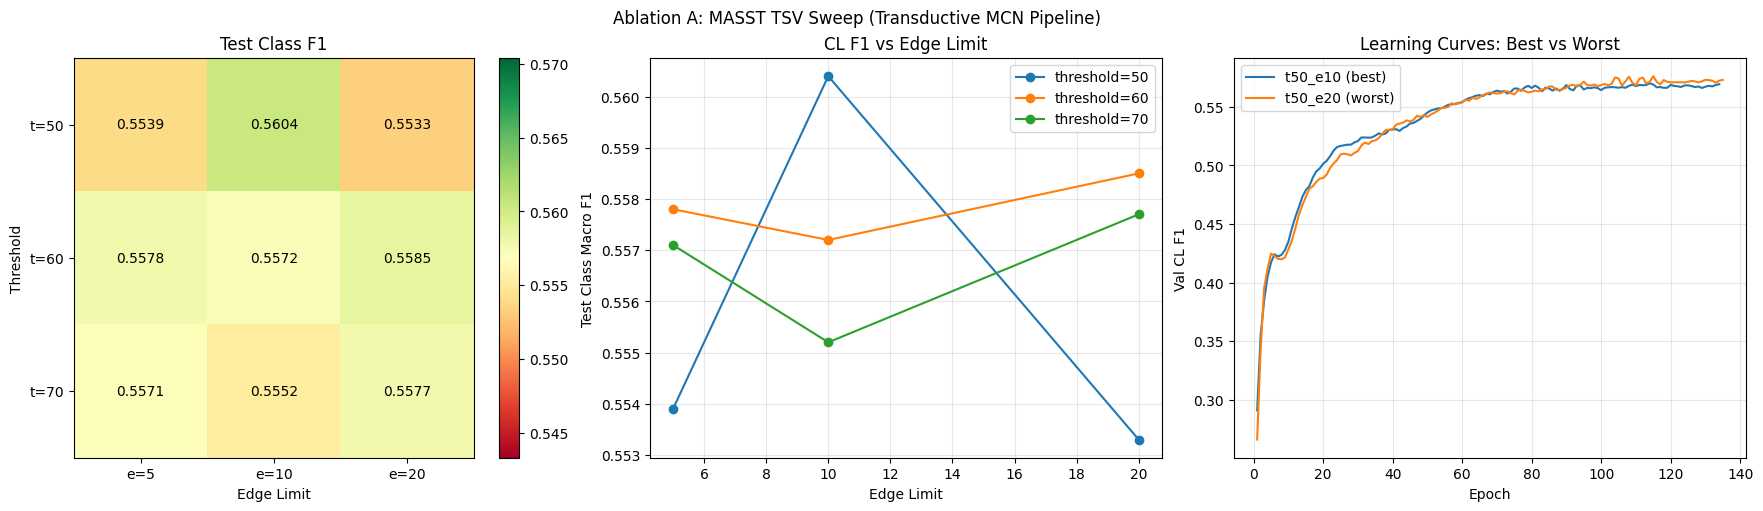

Saved: ablation_a_results.png


In [12]:
thresholds  = [50, 60, 70]
edge_limits = [5, 10, 20]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('Ablation A: MASST TSV Sweep (Transductive MCN Pipeline)', fontsize=12)

ax = axes[0]
cl_f1_mat = np.array([[all_results[f't{t}_e{e}']['cl_f1']
                        for e in edge_limits] for t in thresholds])
im = ax.imshow(cl_f1_mat, cmap='RdYlGn',
               vmin=cl_f1_mat.min()-0.01, vmax=cl_f1_mat.max()+0.01)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([f'e={e}' for e in edge_limits])
ax.set_yticklabels([f't={t}' for t in thresholds])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cl_f1_mat[i,j]:.4f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Test Class F1'); ax.set_xlabel('Edge Limit'); ax.set_ylabel('Threshold')

ax = axes[1]
for t in thresholds:
    f1s = [all_results[f't{t}_e{e}']['cl_f1'] for e in edge_limits]
    ax.plot(edge_limits, f1s, 'o-', label=f'threshold={t}')
ax.set_xlabel('Edge Limit'); ax.set_ylabel('Test Class Macro F1')
ax.set_title('CL F1 vs Edge Limit'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
best_run  = df.iloc[0]['Run']
worst_run = df.iloc[-1]['Run']
for run, lbl in [(best_run, 'best'), (worst_run, 'worst')]:
    curve = all_results[run]['history']['val_cl_f1']
    ax.plot(range(1, len(curve)+1), curve, label=f'{run} ({lbl})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val CL F1')
ax.set_title('Learning Curves: Best vs Worst'); ax.legend(); ax.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, 'ablation_a_results.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_a_results.png')
